# Linear Regression — the Basics

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ujjwal091/ai-ml-course/blob/main/modules/01-supervised-learning/01-linear-regression/01-basics/notes.ipynb)

*Part 1 of 3 on Linear Regression. The first concrete algorithm — fitting a straight line to data, and the
machinery (cost function, gradient descent, R²) that makes "fitting" a precise, repeatable process instead of a
guess.*

**This notebook:** the model, the running example, and gradient descent from scratch.
**Next up:** [Multivariate Regression & Evaluation](../02-multivariate-regression/notes.ipynb), then
[Assumptions & Diagnostics](../03-assumptions-and-diagnostics/notes.ipynb).


## 1. The idea, and the running example

- Linear regression fits a straight line (one feature) or a hyperplane (two or more features) between a target and
  its features.
- Guessing a house's price yourself, you'd weigh location, size, age — those are the *features*; the price is the
  *target*.

**The case study we'll use throughout:** a Japanese automaker entering the US market wants to know what actually
drives car prices there.

- *Which* variables matter for predicting a car's price?
- *How well* do those variables explain the price?

**Dataset:** real Cars24 used-car listings, hosted on GitHub so this notebook runs anywhere. Every numeric column
(including the one-hot flags) has already been through a `StandardScaler` — mean 0, standard deviation 1 — which
is why the raw numbers below look small and centered around zero instead of looking like rupee prices or
kilometers.

- **Input features (X):** `km_driven`, `mileage`, `engine`, `max_power`, `age`, `year`, `make`, `model`, plus
  one-hot flags `Individual`, `Trustmark Dealer`, `Diesel`, `Electric`, `LPG`, `Petrol`, `Manual`, `5`, `>5`.
- **Target (y):** `selling_price`

**Goal:** build a model that predicts a car's selling price from its features.


### 1.1 Load the data

In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

Loading straight from a public URL (rather than a local file) means this notebook runs the same way for anyone
who clones the repo — no separate download step, no dependency on a private drive link.

In [2]:
DATA_URL = "https://raw.githubusercontent.com/28101991SUNNY/DSML-Classical-Machine-Learning-1/main/cars24-car-price-clean.csv"
DATA_PATH = "data/cars24-car-price-clean.csv"

if not os.path.exists(DATA_PATH):
    os.makedirs("data", exist_ok=True)
    pd.read_csv(DATA_URL).to_csv(DATA_PATH, index=False)

df = pd.read_csv(DATA_PATH)  ## Loading the dataset
df.head()  ## Displaying the first 5 rows of the dataset for quick overview

,selling_price,year,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
0,-1.111046,-0.801317,1.195828,0.045745,-1.310754,-1.157780,0.801317,-0.433854,-1.125683,1.248892,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
1,-0.223944,0.450030,-0.737872,-0.140402,-0.537456,-0.360203,-0.450030,-0.327501,-0.333227,1.248892,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
2,-0.915058,-1.426990,0.035608,-0.582501,-0.537456,-0.404885,1.426990,-0.327501,-0.789807,1.248892,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
3,-0.892365,-0.801317,-0.409143,0.329620,-0.921213,-0.693085,0.801317,-0.433854,-0.905265,1.248892,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
4,-0.182683,0.137194,-0.544502,0.760085,0.042999,0.010435,-0.137194,-0.246579,-0.013096,-0.800710,-0.098382,1.014945,-0.020095,-0.056917,-0.975970,0.495818,0.444503,-0.424728


### 1.2 Data notation

Before touching any code, it's worth pinning down the notation used throughout this notebook — it shows up in
every formula from here on.

- We have $n$ historical cars — this is the *training data* we already know the price of.
- Each car has $d$ features: $f_1, f_2, f_3, \ldots, f_d$ (`max_power`, `mileage`, `age`, ...).
- $x_i$ — the full feature vector for the $i$-th car (all $d$ features, one row of the table).
- $y_i$ — the actual price of the $i$-th car (what we're trying to predict).

| | $f_1$ | $f_2$ | $\cdots$ | $f_d$ | $y$ |
|---|---|---|---|---|---|
| car 1 | | | | | $y_1$ |
| car 2 | | | | | $y_2$ |
| $\vdots$ | | $x_i$ (this whole row) | | | $\vdots$ |
| car $n$ | | | | | $y_n$ |

So: $x_i \to$ everything we know about car $i$. $y_i \to$ the one number we're trying to learn to predict from it.


### 1.3 The model as a black box

Once we've used the historical data $(x_i, y_i)$ pairs to build a model, using it is simple: hand it a new,
*unseen* car's features and it hands back a predicted price.


```{mermaid}
graph LR
    A["xq<br/>unseen datapoint"] --> B["Model"] --> C["Predicted price<br/>ŷ"]

    style A fill:#BFDBFE,stroke:#374151,stroke-width:2px,color:#111827
    style B fill:#FDE68A,stroke:#374151,stroke-width:2px,color:#111827
    style C fill:#A7F3D0,stroke:#374151,stroke-width:2px,color:#111827
```

A model is only useful if its prediction $\hat{y}$ (predicted) lands close to the real $y$ (actual) — that's
the entire game from here on: find a model where $\hat{y} \approx y$ as often and as closely as possible.


### 1.4 A tiny worked example, by hand — no code yet

Before the real Cars24 data, it's worth seeing the whole idea work on numbers small enough to do in your head.
Suppose this is all the historical data we have:

| $x_1$ | $x_2$ | $y$ |
|---|---|---|
| 1 | 2 | 4 |
| 2 | 2 | 6 |
| 2 | 3 | 7 |
| 3 | 4 | 10 |

**Can you spot the pattern relating $x_1$, $x_2$ to $y$?**

Try a few combinations before reading on — add them, double one and add the other, anything.


**Quick check**

> What's the rule that turns $(x_1, x_2)$ into $y$ for all four rows above?
>
> $y = 2x_1 + x_2$. Check it: $2(1)+2=4$ ✓, $2(2)+2=6$ ✓, $2(2)+3=7$ ✓, $2(3)+4=10$ ✓.


Now here's the real test — two *new* rows we held back:

| $x_1$ | $x_2$ | $y$ (actual) | $\hat{y}$ (from $y=2x_1+x_2$) |
|---|---|---|---|
| 4 | 4 | 12 | $2(4)+4=12$ ✓ |
| 5 | 4 | 14 | $2(5)+4=14$ ✓ |

Both match exactly — the pattern we found on the first 4 rows generalizes perfectly to rows the "model" never saw
while we were figuring out the rule. That's the entire point of a train/test split, just done by hand: **learn the
pattern on some rows, verify it holds on rows you deliberately held back.**

**Your turn:** using $y = 2x_1 + x_2$, what should $y$ be for $x_1=5, x_2=6$?


**Quick check**

> $x_1=5, x_2=6$ → what's $y$?
>
> $y = 2(5) + 6 = 16$.


## 2. Split the data into training and testing sets

Test size is usually 20% of the data. For a small dataset it's common to bump that to 30%, since a 20% slice might
be too little to evaluate on reliably. `random_state` fixes the random seed, so the split is reproducible — run it
again and you get exactly the same train/test division.


In [3]:
df_train, df_test = train_test_split(df, test_size=0.2, random_state=40)

### 2.1 Choosing a split ratio, and the one rule you can't break

| Data size | Recommended split | Reasoning |
|---|---|---|
| Small (< 5,000 rows) | 80 / 20 | The model needs more data to learn reliably |
| Large (10,000+ rows) | 70 / 30 | A larger test set gives a more confident evaluation |

**The workflow this split is for:**

```{mermaid}
graph TD
    A["Historical data"] -->|split| B["Train set"]
    A -->|split| C["Test set"]
    B --> D["Model building<br/>algorithm learns patterns"]
    D --> E["Predict on Test set<br/>unseen inputs"]
    E --> F["Evaluate<br/>predicted vs. actual"]

    style A fill:#BFDBFE,stroke:#374151,stroke-width:2px,color:#111827
    style D fill:#FDE68A,stroke:#374151,stroke-width:2px,color:#111827
    style F fill:#A7F3D0,stroke:#374151,stroke-width:2px,color:#111827
```

> **Golden rule:** never train on test data. The test set must stay unseen throughout training — otherwise
> whatever metric you compute afterward (R², accuracy, anything) is meaningless, because the model is just
> reciting rows it already memorized, not proving it generalizes.

**The split must be random.** If the data is sorted (say, by year), taking the first 80% as train means the model
never sees recent data during training at all. `train_test_split` shuffles by default — that's not an accident,
it's load-bearing.


## 3. The equation of the line

Linear regression tries to fit a straight line through the data. For one feature:

$$
y = mx + c
$$

For multiple features, that becomes a weighted sum:

$$
y = m_1 x_1 + m_2 x_2 + m_3 x_3 + \cdots + c
$$

where $m_1, m_2, m_3, \ldots$ are the coefficients (one per feature) and $c$ is the intercept. "Fitting" the model
means finding the specific values of every $m_i$ and $c$ that make this line match the data as closely as
possible.

In ML terms, the line parameters get renamed: $m$ becomes the **weight** $w$, $c$ becomes the **bias** $b$. The
feature column values are *inputs*, the target column values are *targets* or *labels*. Same equation, different
vocabulary — you'll see both used interchangeably from here on.


**Try it by hand first:** imagine one feature, and two candidate lines for the same 3 points — `(1, 3)`,
`(2, 5)`, `(3, 6)`.

- Line A: $y = 2x + 1$ → predicts 3, 5, 7 for x = 1, 2, 3. Errors: 0, 0, 1.
- Line B: $y = x + 3$ → predicts 4, 5, 6 for x = 1, 2, 3. Errors: 1, 0, 0.

Both lines get 2 out of 3 points exactly right — so which is actually "better" overall? You need a single number
that scores an entire line at once, not just point-by-point right/wrong. That's exactly what the error function
below is for.


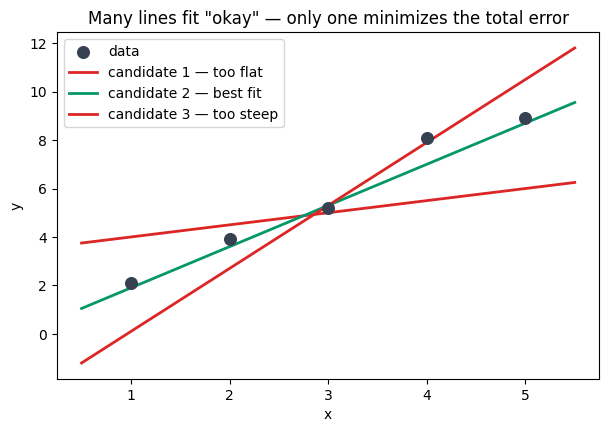

In [4]:
import numpy as np
import matplotlib.pyplot as plt

pts_x = np.array([1, 2, 3, 4, 5])
pts_y = np.array([2.1, 3.9, 5.2, 8.1, 8.9])

xs = np.linspace(0.5, 5.5, 50)
lines = [
    (0.5, 3.5, "#DC2626", "candidate 1 — too flat"),
    (1.7, 0.2, "#059669", "candidate 2 — best fit"),
    (2.6, -2.5, "#DC2626", "candidate 3 — too steep"),
]

plt.figure(figsize=(7, 4.5))
plt.scatter(pts_x, pts_y, color="#374151", zorder=5, s=70, label="data")
for m, c, color, label in lines:
    plt.plot(xs, m * xs + c, color=color, lw=2, label=label)
plt.title("Many lines fit \"okay\" — only one minimizes the total error")
plt.xlabel("x"); plt.ylabel("y")
plt.legend()
plt.show()

## 4. Guessing parameters by hand — why we need gradient descent at all

Before reaching for any formal machinery, it's worth feeling the pain it solves. The obvious first approach: pick
a `w` and `b`, plot the resulting line against the real data, eyeball how far off it is, and try again.


In [5]:
def estimate_charges(x, w, b):
    return w * x + b


def try_parameters(w, b, feature="max_power", target="selling_price"):
    x = df[feature]
    y = df[target]
    estimated = estimate_charges(x, w, b)

    plt.figure(figsize=(8, 5))
    order = np.argsort(x.values)
    plt.plot(x.values[order], estimated.values[order], 'r', alpha=0.9, label='estimate')
    plt.scatter(x, y, s=8, alpha=0.5, label='actual')
    plt.xlabel(feature); plt.ylabel(target)
    plt.legend()
    plt.title(f"w={w}, b={b}")
    plt.show()

**First guess — wildly off.** Since our data is already standardized (roughly in the $[-3, 3]$ range), a slope
of 2 and an intercept of 1 overshoots badly:

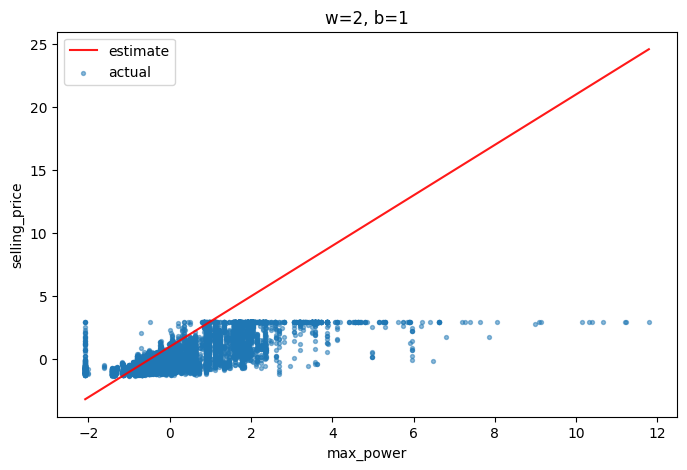

In [6]:
try_parameters(2, 1)

**Second guess — closer, but still not it:**

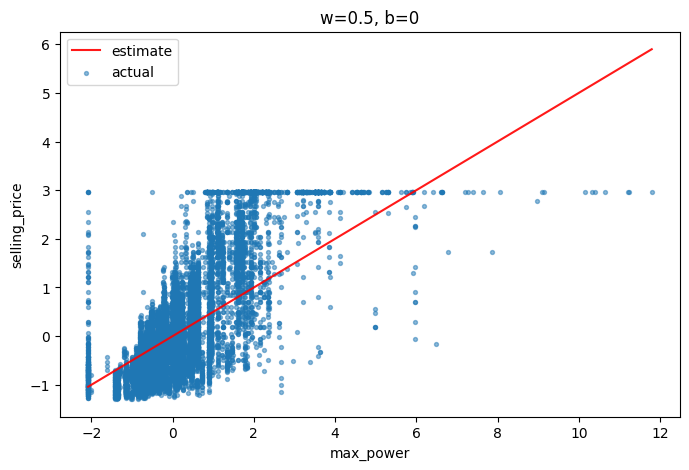

In [7]:
try_parameters(0.5, 0)

**Third guess — getting there, by eye:**

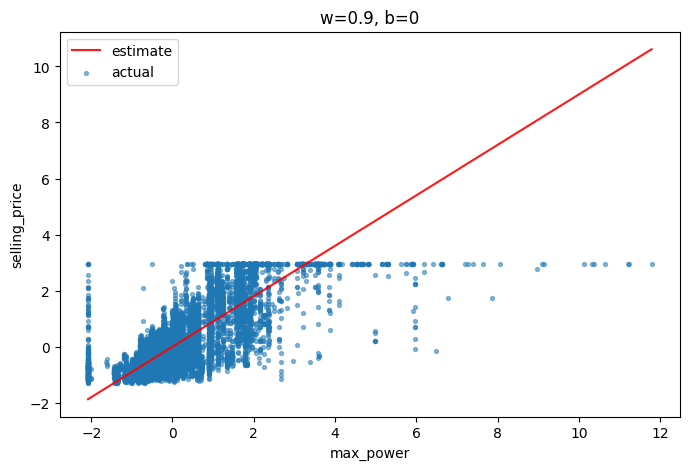

In [8]:
try_parameters(0.9, 0)

> **The problem with manual tuning:** changing `w` and `b` by hand and eyeballing the plot is tedious and
> imprecise — there's no way to tell *how much* better guess 3 is than guess 2 beyond "looks closer." We need a
> number (a cost function) and a systematic way to improve it (an optimizer) — exactly the two ingredients the
> next section names, and exactly what gradient descent (Section 6) automates.


## 5. The three ingredients of every ML algorithm

It's worth naming the pattern explicitly here — because every ML algorithm you'll ever meet, from this simple
line all the way to massive neural networks, is built from exactly three parts:

```{mermaid}
graph LR
    A["🏗️ Model<br/>makes predictions<br/>e.g. y = wx + b"] --> B["📉 Cost Function<br/>measures how wrong<br/>e.g. MSE"]
    B --> C["🔄 Optimizer<br/>adjusts the model<br/>e.g. Gradient Descent"]
    C -.->|repeat| A

    style A fill:#BFDBFE,stroke:#374151,stroke-width:2px,color:#111827
    style B fill:#FDE68A,stroke:#374151,stroke-width:2px,color:#111827
    style C fill:#A7F3D0,stroke:#374151,stroke-width:2px,color:#111827
```

- **Model** — the equation that turns features into a prediction. For us: $y = mx + c$.
- **Cost function** — a single number scoring how wrong the model currently is. For us: Mean Squared Error.
- **Optimizer** — the algorithm that nudges the model's parameters to make the cost function smaller. For us:
  Gradient Descent.

Once you can name these three pieces for *any* algorithm, you can instantly orient yourself in it — swap out the
model (a neural network instead of a line), the cost function (cross-entropy instead of MSE), or the optimizer
(Adam instead of plain gradient descent), and the loop is exactly the same shape. The rest of this section makes
all three precise for linear regression specifically.


## 6. Prediction, error, and gradient descent

**The training loop, in one sentence:** start with a random guess for $m$ and $c$ → use them to predict
$y_{predicted} = mx + c$ → measure how wrong that guess is → nudge $m$ and $c$ in the direction that makes it
*less* wrong → repeat until it stops improving.

The rest of this section is just making "measure how wrong" and "nudge in the right direction" precise.

### 6.1 Measuring "how wrong" — Mean Squared Error (MSE)

$$
Error = \frac{1}{n} \sum (y - y_{predicted})^2
$$

- Square each point's error before summing — that stops positive and negative misses from canceling out, and
  punishes big misses harder than small ones.
- Averaging over all $n$ points turns "how wrong is this one prediction" into "how wrong is this entire line" —
  a single number you can compare across candidate lines.
- This formula has the same shape as $x^2$ — **convex**, meaning one single lowest point (global minimum) and no
  other dips to get stuck in. That matters for the next step: it's exactly what makes "always walk downhill"
  a strategy that's guaranteed to work.


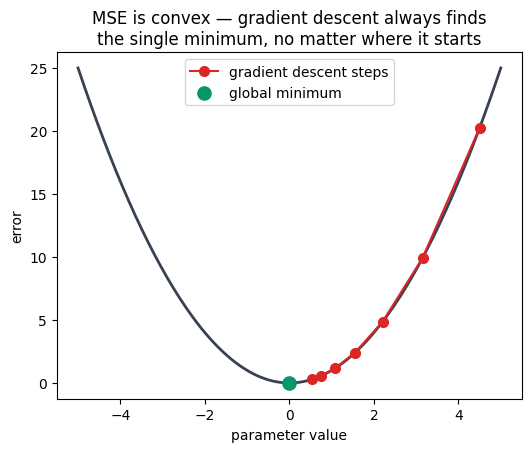

In [9]:
import numpy as np
import matplotlib.pyplot as plt

xs = np.linspace(-5, 5, 200)
ys = xs**2

# a few steps of gradient descent on f(x) = x^2, starting at x=4.5
path_x = [4.5]
lr = 0.15
for _ in range(6):
    grad = 2 * path_x[-1]
    path_x.append(path_x[-1] - lr * grad)
path_y = [x**2 for x in path_x]

plt.figure(figsize=(6, 4.5))
plt.plot(xs, ys, color="#374151", lw=2)
plt.plot(path_x, path_y, "o-", color="#DC2626", markersize=7, lw=1.5, label="gradient descent steps")
plt.scatter([0], [0], color="#059669", zorder=5, s=90, label="global minimum")
plt.title("MSE is convex — gradient descent always finds\nthe single minimum, no matter where it starts")
plt.xlabel("parameter value"); plt.ylabel("error")
plt.legend()
plt.show()

### 6.2 Walking downhill — gradient descent

The **gradient** is just the slope of the error curve at your current guess. It always points in the direction
the error *increases* fastest — so to make the error smaller, you step the opposite way. That's the entire idea;
everything below is just writing it as a formula.

**General update rule**, for any parameter `x`:

$$
x = x - \text{learning_rate} \cdot \frac{d(Error)}{dx}
$$

- `learning_rate` (also called step size) — how big a step to take each round. Too small and training crawls;
  too large and it overshoots the minimum and can bounce around instead of settling.
- $\frac{d(Error)}{dx}$ — the slope of the error curve at `x`'s current value.

For plain $Error = x^2$, the slope is $2x$, so the rule becomes $x = x - \text{learning_rate} \cdot 2x$ — exactly
the steps the plot above just walked through.

### 6.3 Applying it to our actual parameters, $m$ and $c$

Substitute the real prediction $y_{predicted} = mx + c$ into the error formula:

$$
Error = \frac{1}{n} \sum (y - (mx + c))^2
$$

Now take the slope *separately* for each parameter — how much the error moves if you nudge just $m$ (holding $c$
fixed), and how much it moves if you nudge just $c$ (holding $m$ fixed):

$$
\frac{d(Error)}{dm} = -\frac{2}{n} \sum (y - (mx + c)) \cdot x
\qquad\qquad
\frac{d(Error)}{dc} = -\frac{2}{n} \sum (y - (mx + c))
$$

**Notice the two formulas are identical except for one thing** — the $m$ version has an extra $\cdot\, x$ tacked
on. That's not arbitrary: $m$ multiplies $x$ inside the prediction, so a 1-unit nudge to $m$ moves the prediction
by $x$ units, not 1. $c$ has no such multiplier — nudging it moves the prediction by exactly however much you
nudged it. That's the whole reason the two gradients look different.

**Update rules**, using those two slopes:

$$
m = m - \text{learning_rate} \cdot \frac{d(Error)}{dm}
\qquad\qquad
c = c - \text{learning_rate} \cdot \frac{d(Error)}{dc}
$$

### 6.4 The full loop, one more time

random $m, c$ → predict → measure MSE → compute both gradients → update $m$ and $c$ → repeat until the error
stops meaningfully improving.


**Quick check**

> Why does gradient descent *subtract* the gradient rather than add it?
>
> The gradient points in the direction the error *increases* fastest. To make the error smaller, you move the
> opposite way — hence the minus sign in every update rule above. If you added the gradient instead, you'd be
> deliberately climbing uphill, and the error would grow with every step instead of shrinking.


## 7. R-squared (coefficient of determination)

- Question R² answers: **is this fitted line actually good?**
- How: compare your model's error against the simplest possible baseline — always predicting the average `y`.

$$
R^2 = 1 - \frac{RSS}{TSS}
$$

- $TSS = \sum (y - \bar{y})^2$ — error of the "always predict the mean" baseline.
- $RSS = \sum (y - y_{predicted})^2$ — error of the model you're actually evaluating.


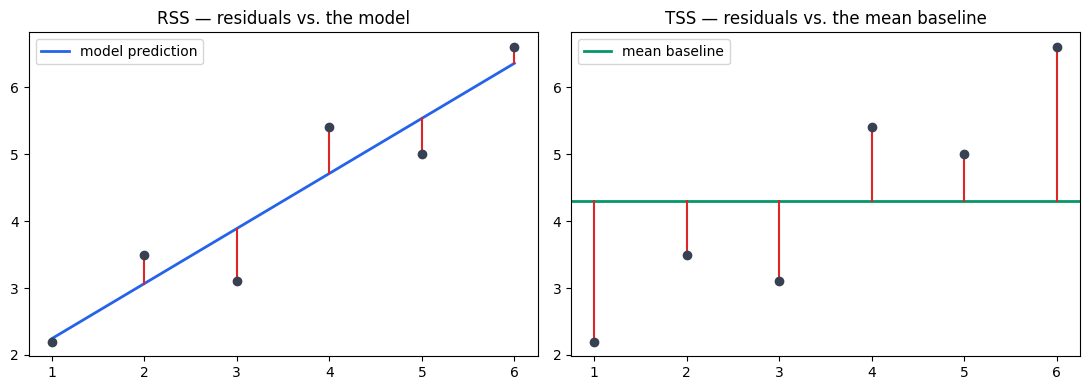

RSS (model)   : 1.63
TSS (baseline): 13.48
R-squared     : 0.879


In [10]:
toy_x = np.array([1, 2, 3, 4, 5, 6])
toy_y = np.array([2.2, 3.5, 3.1, 5.4, 5.0, 6.6])
m_fit, c_fit = np.polyfit(toy_x, toy_y, 1)
toy_pred = m_fit * toy_x + c_fit
toy_mean = np.mean(toy_y)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(toy_x, toy_y, color="#374151", zorder=5)
axes[0].plot(toy_x, toy_pred, color="#2563EB", lw=2, label="model prediction")
for x, y, p in zip(toy_x, toy_y, toy_pred):
    axes[0].plot([x, x], [y, p], color="#DC2626", lw=1.5)
axes[0].set_title("RSS — residuals vs. the model")
axes[0].legend()

axes[1].scatter(toy_x, toy_y, color="#374151", zorder=5)
axes[1].axhline(toy_mean, color="#059669", lw=2, label="mean baseline")
for x, y in zip(toy_x, toy_y):
    axes[1].plot([x, x], [y, toy_mean], color="#DC2626", lw=1.5)
axes[1].set_title("TSS — residuals vs. the mean baseline")
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"RSS (model)   : {np.sum((toy_y - toy_pred)**2):.2f}")
print(f"TSS (baseline): {np.sum((toy_y - toy_mean)**2):.2f}")
print(f"R-squared     : {1 - np.sum((toy_y - toy_pred)**2)/np.sum((toy_y - toy_mean)**2):.3f}")

**Reading the number:**
- $R^2 \approx 1$ → excellent fit — model's red lines (left) are much shorter than the baseline's (right).
- $R^2 \approx 0$ → no better than just guessing the average every time.
- $R^2 < 0$ → *worse* than the average-guessing baseline — the chosen $m$, $c$ are genuinely poor.
- Range: $(-\infty, 1]$.

**One line:** R² measures how much of the variance in the data your model explains, versus just predicting the
mean every time.


## 8. Building it from scratch — one feature first

Starting simple: predicting `selling_price` from `max_power` alone. Notice it scales `x` first (subtracts the
mean, divides by the standard deviation), because gradient descent converges far more reliably when features are
on a similar scale — see the [Feature Scaling notes](../../../data-preprocessing/feature-scaling/notes.ipynb) for
why.


In [11]:
def regression(x, y, m=1, c=0, learning_rate=0.001, threshold=0.001, max_iter=1000):
    # scaling the data.. will be described below
    x = (x - np.mean(x)) / np.std(x)

    n = len(x)
    prev_error = float('inf')

    for _ in range(max_iter):
        y_predicted = m * x + c
        # error = (1/n) * sum((y - y_predicted) ** 2)
        error = np.mean((y_predicted - y) ** 2)

        if abs(prev_error - error) < threshold:
            break

        # Calculate gradients
        dm = (-2 / n) * sum((y - y_predicted) * x)
        dc = (-2 / n) * sum(y - y_predicted)

        # Update parameters
        m = m - learning_rate * dm
        c = c - learning_rate * dc

        prev_error = error

    return m, c

In [12]:
regression(x=df['max_power'], y=df['selling_price'])

(0.9995407797091496, -1.4925833861837496e-19)

## 9. Generalizing to multiple features

The single-feature version only handles one $m$. Real problems have several features at once — `max_power` and
`mileage` together, say — so let's generalize it: `m` becomes a weight *vector* `w` (one weight per feature), and
the math becomes matrix operations instead of a single multiply.


In [13]:
import numpy as np
from typing import Tuple, Optional


def regression(
        x: np.ndarray,  # (n_samples, n_features)
        y: np.ndarray,  # (n_samples,)
        w: Optional[np.ndarray] = None,  # (n_features,)
        b: float = 0.0,
        learning_rate: float = 0.01,
        threshold: float = 1e-6,
        max_iter: int = 1000
) -> Tuple[np.ndarray, float]:
    # Ensure numpy arrays
    x = np.asarray(x)
    x = (x - np.mean(x, axis=0)) / np.std(x, axis=0)

    y = np.asarray(y)

    n, n_features = x.shape

    # Initialize weights if not provided
    if w is None:
        w = np.zeros(n_features)

    prev_error = float('inf')

    for _ in range(max_iter):

        # Predictions
        y_predicted = np.dot(x, w) + b

        # Mean Squared Error
        error = np.mean((y_predicted - y) ** 2)

        # Convergence check
        if abs(prev_error - error) < threshold:
            break

        # Gradients
        dw = (2 / n) * np.dot(x.T, (y_predicted - y))
        db = (2 / n) * np.sum(y_predicted - y)

        # Update
        w -= learning_rate * dw
        b -= learning_rate * db

        prev_error = error

    return w, b

In [14]:
x = df[['max_power', 'mileage']].values
y = df['selling_price'].values

regression(x, y)

(array([0.79434556, 0.05793132]), np.float64(-5.550263690735546e-17))

## 10. Scoring the fit with R²

In [15]:
def calculate_r_squared(y_true, y_pred):
    mean = np.mean(y_true)
    rss = np.sum((y_true - y_pred) ** 2)
    tss = np.sum((y_true - mean) ** 2)

    return 1 - (rss / tss)

In [16]:
# Train
w, b = regression(x, y)

# Manually scale x the same way
x_scaled = (x - np.mean(x, axis=0)) / np.std(x, axis=0)

# Predict
predicted_car_price = np.dot(x_scaled, w) + b

# R2
r_squared = calculate_r_squared(y, predicted_car_price)
print(f"R-squared: {r_squared:.4f}")

R-squared: 0.5967


## 11. Same thing, using scikit-learn
Once you understand what's happening underneath, this is the version you'd actually reach for day to day.

In [17]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x, y)

print(model.coef_)
print(model.intercept_)

[0.80097416 0.0645545 ]
-1.1871485866889763e-16


In [18]:
predicted_car_price = model.predict(x)
r_squared = calculate_r_squared(y, predicted_car_price)
print(f"R-squared: {r_squared:.4f}")

R-squared: 0.5967


Only 2 of the 17 available features so far, and already R² ≈ 0.6. What happens if we stop leaving 15 features on
the table? That's exactly where the next notebook picks up.


## 12. Summary — revision cheat sheet

**The model:** $y = mx + c$ (one feature) or $y = m_1x_1 + m_2x_2 + \cdots + c$ (many). Every ML algorithm
reduces to the same three ingredients: **Model** (predicts), **Cost Function** (scores the error), **Optimizer**
(reduces it).

**Fitting it — the loop:** start with random $m$, $c$ → predict → measure error with MSE → nudge $m$, $c$ downhill
via gradient descent → repeat until the error stops meaningfully improving.

**Core definitions:**
- *MSE (the cost function)* — $\frac{1}{n}\sum(y - y_{predicted})^2$; convex, so it has a single global minimum
  and gradient descent always finds it.
- *Gradient descent (the optimizer)* — repeatedly step each parameter opposite its gradient:
  $x = x - \text{learning_rate} \cdot \frac{d(Error)}{dx}$.
- *R² (coefficient of determination)* — $1 - RSS/TSS$; how much better your model does than just predicting the
  mean every time. Range $(-\infty, 1]$; near 1 is a great fit, near 0 is no better than the mean, negative is
  worse than the mean.
- *Feature scaling* — subtract the mean, divide by the standard deviation, before fitting. Both from-scratch
  implementations above do this internally; it's what makes gradient descent converge reliably.

**Practical must-do:** always split into train/test before fitting, and never let the model see the test set
during training — that's the only way the R² (or any other metric) you compute afterward actually means anything.

**Next up:** [Multivariate Regression & Evaluation](../02-multivariate-regression/notes.ipynb) — using every one
of the 17 available features at once, reading coefficients, outliers, Adjusted R², and StatsModels.
